# ST3247 Advanced Methods
## Regression Adjustment | Random Forest | Synthetic Likelihood | ABC-MCMC

## Set up

In [1]:
import time; import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, gaussian_kde, multivariate_normal
from numpy.linalg import lstsq
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


from updated_simulator import simulate 

from helpers import (calc_summaries, SUMMARY_NAMES, load_observed_summaries,
                    sample_prior_theta, generate_prior_bank,
                    abc_rejection, PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO,
                    FINAL_JOINT)

In [2]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewire_obs   = pd.read_csv("data/rewiring_timeseries.csv")
degree_obs   = pd.read_csv("data/final_degree_histograms.csv")

s_obs = load_observed_summaries(infected_obs, rewire_obs, degree_obs)

In [3]:
N_SIM = 100_000

if os.path.exists("params_prior.npy") and os.path.exists("sims_prior.npy"):
    print("Found saved files — loading...")
    params_prior = np.load("params_prior.npy")
    sims_prior   = np.load("sims_prior.npy")
    print(f"Loaded {len(params_prior):,} simulations.")

else:
    print(f"Running {N_SIM:,} simulations...")
    
    rng_prior = np.random.default_rng(7)
    t0 = time.perf_counter()
    
    params_prior, sims_prior = generate_prior_bank(simulate, N_SIM, rng_prior, verbose=True)
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    
    np.save("params_prior.npy", params_prior)
    np.save("sims_prior.npy", sims_prior)

print(f"\nparams_prior shape: {params_prior.shape}")
print(f"sims_prior shape:   {sims_prior.shape}")

Found saved files — loading...
Loaded 100,000 simulations.

params_prior shape: (100000, 3)
sims_prior shape:   (100000, 24)


In [4]:
# rescales all statistics to the same scale so no single statistic dominates the distance calculation

s_std = sims_prior.std(axis=0)
s_std[s_std == 0] = 1.0  # avoid divide by zero

sims_norm  = sims_prior / s_std
s_obs_norm = s_obs      / s_std


## Baseline: Rejection ABC

In [5]:
# Get accepted samples using the best summary subset
params_accepted, mask, threshold = abc_rejection(
    s_obs_norm, sims_norm, params_prior,
    stat_indices=FINAL_JOINT,
    acceptance_rate=0.02   # accept closest 2%
)

sims_accepted = sims_prior[mask]  # their summary vectors

print(f"Threshold distance: {threshold:.4f}")
print(f"Number accepted:    {len(params_accepted)}")
print(f"\nPosterior means (before regression adjustment):")
print(f"  beta  = {params_accepted[:, 0].mean():.4f} ± {params_accepted[:, 0].std():.4f}")
print(f"  gamma = {params_accepted[:, 1].mean():.4f} ± {params_accepted[:, 1].std():.4f}")
print(f"  rho   = {params_accepted[:, 2].mean():.4f} ± {params_accepted[:, 2].std():.4f}")

Threshold distance: 1.1815
Number accepted:    2001

Posterior means (before regression adjustment):
  beta  = 0.1893 ± 0.0481
  gamma = 0.0897 ± 0.0168
  rho   = 0.3330 ± 0.0802


## Method 1: Regression Adjustment

In [6]:
def regression_adjustment(params_accepted, sims_accepted, s_obs, stat_indices):
    """
    Beaumont et al. (2002) regression adjustment.
    
    For each accepted sample, we know how far its summaries were
    from the observed. We fit a linear regression to correct for
    that gap, shifting each parameter estimate toward where it
    would land if summaries matched perfectly.
    """
    # How far were each accepted sample's summaries from observed?
    residuals = sims_accepted[:, stat_indices] - s_obs[stat_indices]
    
    # Add intercept column
    X = np.column_stack([np.ones(len(residuals)), residuals])
    
    params_adjusted = np.empty_like(params_accepted)
    
    for j in range(3):  # for each of beta, gamma, rho
        y = params_accepted[:, j]
        
        # Fit linear regression
        coeffs, _, _, _ = lstsq(X, y, rcond=None)
        
        # Remove the part explained by the summary gap
        correction = X @ coeffs - coeffs[0]
        params_adjusted[:, j] = y - correction
    
    return params_adjusted

# Apply it!
params_adjusted = regression_adjustment(
    params_accepted, sims_accepted, s_obs, FINAL_JOINT
)

print(f"\nPosterior means (AFTER regression adjustment):")
print(f"  beta  = {params_adjusted[:, 0].mean():.4f} ± {params_adjusted[:, 0].std():.4f}")
print(f"  gamma = {params_adjusted[:, 1].mean():.4f} ± {params_adjusted[:, 1].std():.4f}")
print(f"  rho   = {params_adjusted[:, 2].mean():.4f} ± {params_adjusted[:, 2].std():.4f}")


Posterior means (AFTER regression adjustment):
  beta  = 0.1652 ± 0.0228
  gamma = 0.0818 ± 0.0065
  rho   = 0.3140 ± 0.0263


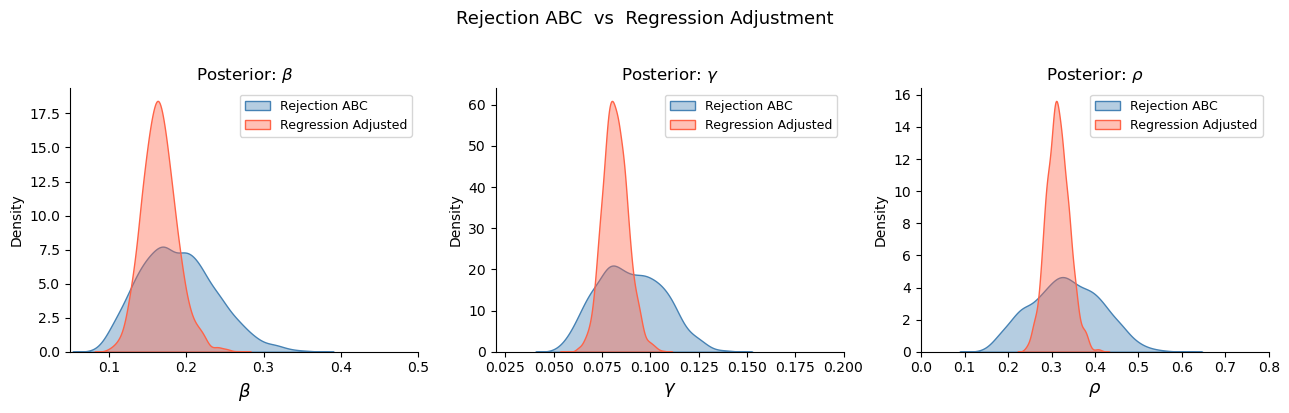

In [7]:
PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(params_accepted[:, j], ax=ax, color="steelblue",
                fill=True, alpha=0.4, label="Rejection ABC", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.4, label="Regression Adjusted", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Rejection ABC  vs  Regression Adjustment", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'ABC mean':>10} {'ABC std':>10} {'Adj mean':>10} {'Adj std':>10}")
# adj mean, adj std are values after regression adjustment
print("-" * 52)
for j, label in enumerate(labels):
    m1 = params_accepted[:, j].mean()
    s1 = params_accepted[:, j].std()
    m2 = params_adjusted[:, j].mean()
    s2 = params_adjusted[:, j].std()
    print(f"{label:<10} {m1:>10.4f} {s1:>10.4f} {m2:>10.4f} {s2:>10.4f}")

print("\nSmaller std = sharper posterior = better inference")

Parameter    ABC mean    ABC std   Adj mean    Adj std
----------------------------------------------------
beta           0.1893     0.0481     0.1652     0.0228
gamma          0.0897     0.0168     0.0818     0.0065
rho            0.3330     0.0802     0.3140     0.0263

Smaller std = sharper posterior = better inference


In [9]:
prior_std = np.array([
    (PRIOR_BETA[1]  - PRIOR_BETA[0])  / np.sqrt(12),
    (PRIOR_GAMMA[1] - PRIOR_GAMMA[0]) / np.sqrt(12),
    (PRIOR_RHO[1]   - PRIOR_RHO[0])   / np.sqrt(12),
])

labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'Prior std':>10} {'ABC std':>10} {'Reg std':>10} {'Contraction':>12}")
print("-" * 48)
for j, label in enumerate(labels):
    abc_std = params_accepted[:, j].std()
    reg_std = params_adjusted[:, j].std()
    contraction = 1 - reg_std / prior_std[j]
    print(f"{label:<10} {prior_std[j]:>10.4f} {abc_std:>10.4f} {reg_std:>10.4f} {contraction:>11.1%}")

print("\nContraction = how much uncertainty shrank vs the prior")
print("Higher % = more information learned about that parameter")

Parameter   Prior std    ABC std    Reg std  Contraction
------------------------------------------------
beta           0.1299     0.0481     0.0228       82.4%
gamma          0.0520     0.0168     0.0065       87.4%
rho            0.2309     0.0802     0.0263       88.6%

Contraction = how much uncertainty shrank vs the prior
Higher % = more information learned about that parameter


## Method 2: Random Forest

In [10]:
# Train one Random Forest for each parameter
rf_beta  = RandomForestRegressor(n_estimators=200, random_state=42)
rf_gamma = RandomForestRegressor(n_estimators=200, random_state=42)
rf_rho   = RandomForestRegressor(n_estimators=200, random_state=42)

print("Training Random Forests...")
t0 = time.perf_counter()

rf_beta.fit(sims_prior,  params_prior[:, 0])
rf_gamma.fit(sims_prior, params_prior[:, 1])
rf_rho.fit(sims_prior,   params_prior[:, 2])

t1 = time.perf_counter()
print(f"Done in {t1-t0:.1f}s")
print("\n3 forests trained:")
print("  rf_beta  → predicts β")
print("  rf_gamma → predicts γ")
print("  rf_rho   → predicts ρ")

Training Random Forests...
Done in 856.7s

3 forests trained:
  rf_beta  → predicts β
  rf_gamma → predicts γ
  rf_rho   → predicts ρ


In [11]:
# Feed observed summaries into each trained forest
beta_pred  = rf_beta.predict(s_obs.reshape(1, -1))[0]
gamma_pred = rf_gamma.predict(s_obs.reshape(1, -1))[0]
rho_pred   = rf_rho.predict(s_obs.reshape(1, -1))[0]

print("Random Forest predictions for observed data:")
print(f"  beta  = {beta_pred:.4f}")
print(f"  gamma = {gamma_pred:.4f}")
print(f"  rho   = {rho_pred:.4f}")

print("\nCompare with Regression Adjustment:")
print(f"  beta  = {params_adjusted[:, 0].mean():.4f}")
print(f"  gamma = {params_adjusted[:, 1].mean():.4f}")
print(f"  rho   = {params_adjusted[:, 2].mean():.4f}")

Random Forest predictions for observed data:
  beta  = 0.1606
  gamma = 0.0798
  rho   = 0.2967

Compare with Regression Adjustment:
  beta  = 0.1652
  gamma = 0.0818
  rho   = 0.3140


In [12]:
print("Cross-validation R² scores (higher = better, max=1.0):")
print("(This tells us how well the forest predicts each parameter)")
print()

for name, rf in [("beta", rf_beta), ("gamma", rf_gamma), ("rho", rf_rho)]:
    scores = cross_val_score(rf, sims_prior, 
                            params_prior[:, ["beta","gamma","rho"].index(name)],
                            cv=5, scoring="r2")
    print(f"  {name:<6}  R² = {scores.mean():.3f} ± {scores.std():.3f}")

print()

Cross-validation R² scores (higher = better, max=1.0):
(This tells us how well the forest predicts each parameter)

  beta    R² = 0.925 ± 0.001
  gamma   R² = 0.951 ± 0.002
  rho     R² = 0.975 ± 0.000



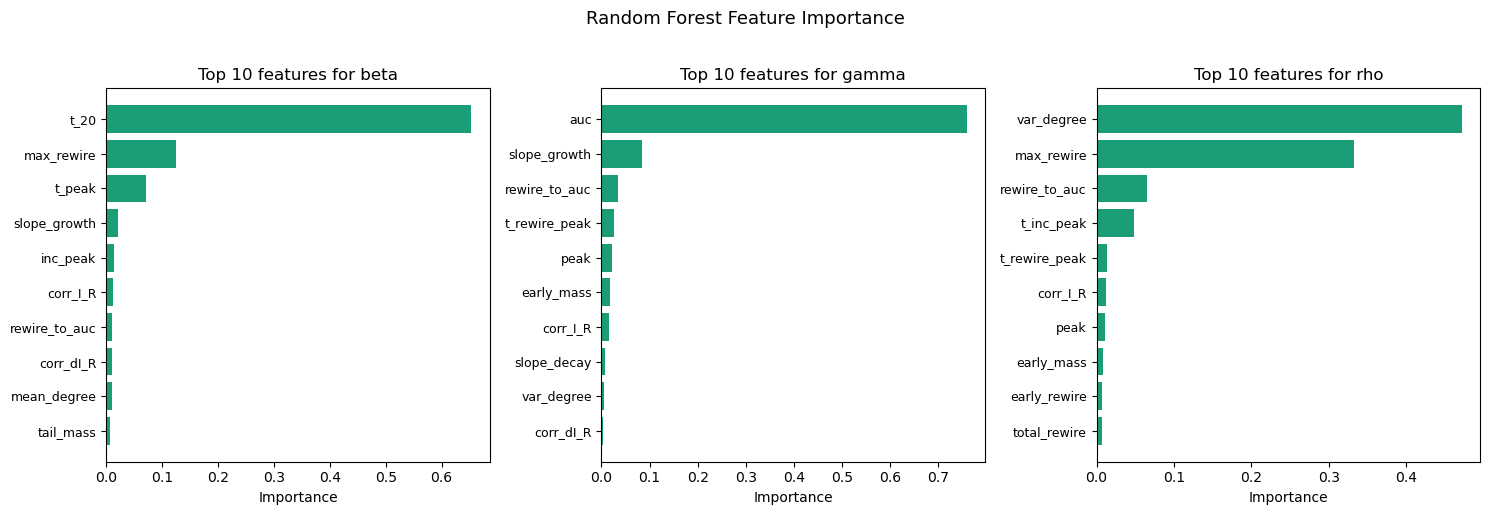

In [13]:
# Feature Importance

PALETTE = sns.color_palette("Dark2")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, rf) in zip(axes, [("beta", rf_beta), ("gamma", rf_gamma), ("rho", rf_rho)]):
    importances = rf.feature_importances_
    # Sort by importance
    idx = np.argsort(importances)[::-1][:10]  # top 10 only
    
    ax.barh(range(10), importances[idx][::-1], color=PALETTE[0])
    ax.set_yticks(range(10))
    ax.set_yticklabels([SUMMARY_NAMES[i] for i in idx[::-1]], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 10 features for {name}")

plt.suptitle("Random Forest Feature Importance", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Method 3: Synthetic Likelihood

For a given (β, γ, ρ), we run the simulator multiple times to estimate the mean and covariance of the summary statistics. We then treat the summaries as multivariate normal and compute how likely the observed summaries are under that distribution. MCMC is used to explore the parameter space.


In [14]:
def synthetic_likelihood(theta, s_obs, n_sims=50, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    beta, gamma, rho = theta
    
    if not (0.05 <= beta <= 0.50):  return -np.inf
    if not (0.02 <= gamma <= 0.20): return -np.inf
    if not (0.00 <= rho <= 0.80):   return -np.inf
    
    # Run simulations - apply FINAL_JOINT subset here
    sim_summaries = []
    for _ in range(n_sims):
        inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
        sim_summaries.append(calc_summaries(inf, rew, deg)[FINAL_JOINT])
    sim_summaries = np.array(sim_summaries)
    
    mu    = sim_summaries.mean(axis=0)
    Sigma = np.cov(sim_summaries, rowvar=False)
    Sigma += 1e-3 * np.eye(len(mu))
    
    # s_obs subset already matches - don't apply FINAL_JOINT again!
    s_obs_sub = s_obs[FINAL_JOINT]
    
    try:
        log_lik = multivariate_normal.logpdf(s_obs_sub, mean=mu, cov=Sigma)
        if not np.isfinite(log_lik):
            return -np.inf
        return log_lik
    except:
        return -np.inf

# Test again
rng_test = np.random.default_rng(0)
test_ll = synthetic_likelihood(np.array([0.16, 0.08, 0.31]), s_obs, n_sims=50, rng=rng_test)
print(f"Test log likelihood: {test_ll:.4f}")


Test log likelihood: 3.5254


In [15]:
def run_mcmc_sl(s_obs, n_steps=3000, n_sims=50, seed=42):
    rng = np.random.default_rng(seed)
    
    # Start from known estimates
    theta_current = np.array([0.16, 0.08, 0.31])
    ll_current    = synthetic_likelihood(theta_current, s_obs, n_sims=n_sims, rng=rng)
    
    print(f"Starting log likelihood: {ll_current:.4f}")
    
    chain    = np.zeros((n_steps, 3))
    accepted = 0
    proposal_std = np.array([0.01, 0.005, 0.02])
    
    print(f"Running MCMC for {n_steps} steps...")
    t0 = time.perf_counter()
    
    for i in range(n_steps):
        theta_proposed = theta_current + rng.normal(0, proposal_std)
        ll_proposed    = synthetic_likelihood(theta_proposed, s_obs, n_sims=n_sims, rng=rng)
        
        log_alpha = ll_proposed - ll_current
        if np.log(rng.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted += 1
        
        chain[i] = theta_current
        
        if (i + 1) % 500 == 0:
            print(f"  Step {i+1}/{n_steps}  |  acceptance rate: {accepted/(i+1):.1%}  |  current: beta={theta_current[0]:.3f}, gamma={theta_current[1]:.3f}, rho={theta_current[2]:.3f}")
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    print(f"Overall acceptance rate: {accepted/n_steps:.1%}")
    print("(Good acceptance rate is between 20% and 50%)")
    
    return chain

chain_sl = run_mcmc_sl(s_obs, n_steps=3000, n_sims=50, seed=42)

Starting log likelihood: 4.2706
Running MCMC for 3000 steps...


  Step 500/3000  |  acceptance rate: 38.8%  |  current: beta=0.169, gamma=0.080, rho=0.322
  Step 1000/3000  |  acceptance rate: 36.1%  |  current: beta=0.149, gamma=0.079, rho=0.289
  Step 1500/3000  |  acceptance rate: 35.7%  |  current: beta=0.163, gamma=0.076, rho=0.290
  Step 2000/3000  |  acceptance rate: 35.1%  |  current: beta=0.142, gamma=0.077, rho=0.265
  Step 2500/3000  |  acceptance rate: 34.7%  |  current: beta=0.174, gamma=0.081, rho=0.359
  Step 3000/3000  |  acceptance rate: 33.9%  |  current: beta=0.154, gamma=0.080, rho=0.305

Done in 561.8s
Overall acceptance rate: 33.9%
(Good acceptance rate is between 20% and 50%)


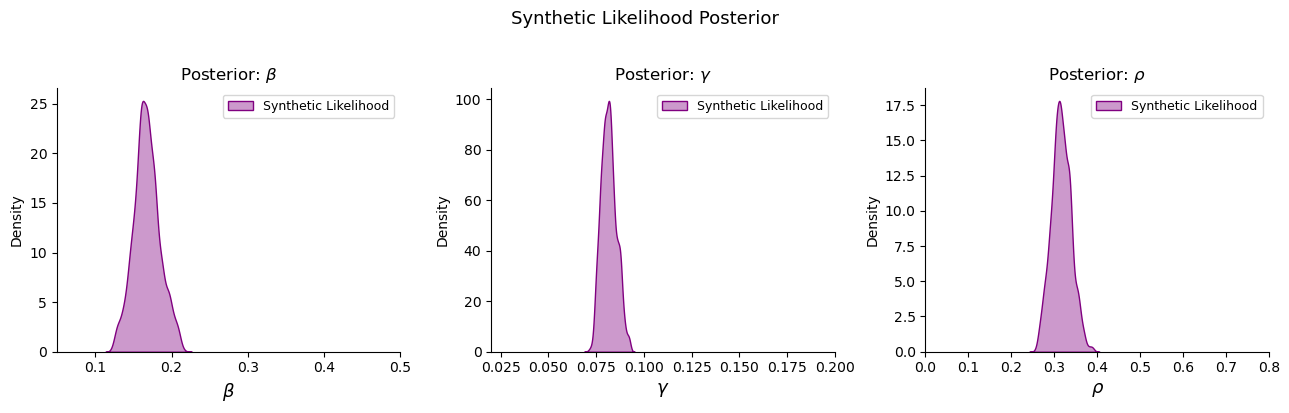

In [16]:
# Solo Synthetic Likelihood posterior

# Discard first 500 steps (burn-in period)
# Burn-in: early steps where chain is still finding its way
burnin = 500
chain_sl_trimmed = chain_sl[burnin:]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.4, label="Synthetic Likelihood", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Synthetic Likelihood Posterior", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

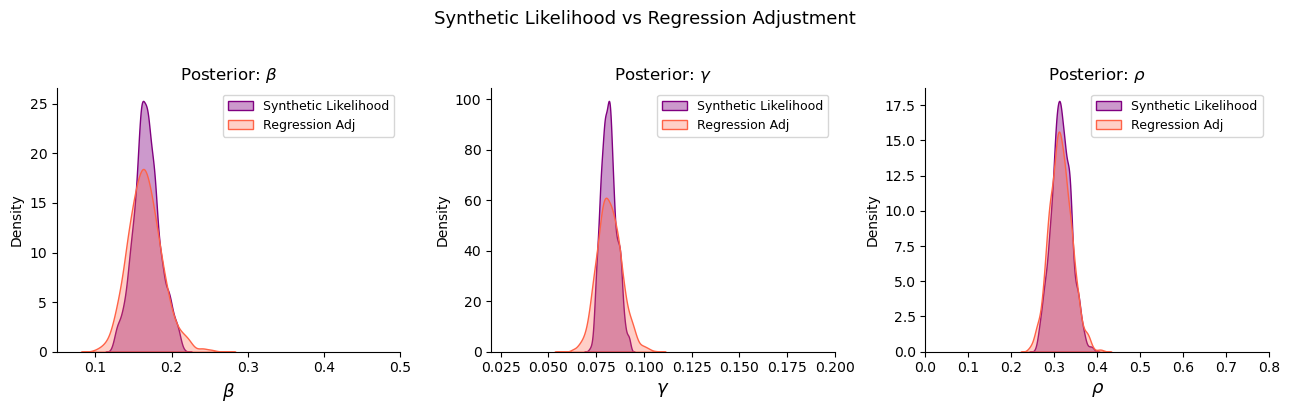


Synthetic Likelihood posterior means:
  beta  = 0.1671 ± 0.0169
  gamma = 0.0815 ± 0.0040
  rho   = 0.3157 ± 0.0228


In [17]:
PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.4, label="Synthetic Likelihood", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Synthetic Likelihood vs Regression Adjustment", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print("\nSynthetic Likelihood posterior means:")
print(f"  beta  = {chain_sl_trimmed[:, 0].mean():.4f} ± {chain_sl_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_sl_trimmed[:, 1].mean():.4f} ± {chain_sl_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_sl_trimmed[:, 2].mean():.4f} ± {chain_sl_trimmed[:, 2].std():.4f}")

In [18]:
print("Synthetic Likelihood posterior means (after burn-in):")
print(f"  beta  = {chain_sl_trimmed[:, 0].mean():.4f} ± {chain_sl_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_sl_trimmed[:, 1].mean():.4f} ± {chain_sl_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_sl_trimmed[:, 2].mean():.4f} ± {chain_sl_trimmed[:, 2].std():.4f}")

Synthetic Likelihood posterior means (after burn-in):
  beta  = 0.1671 ± 0.0169
  gamma = 0.0815 ± 0.0040
  rho   = 0.3157 ± 0.0228


## Method 4: ABC-MCMC

Using MCMC within the ABC framework.
Instead of blind rejection sampling, we propose parameters near the current point and accept/reject based on the ABC distance criterion.

In [19]:
def run_abc_mcmc(s_obs_norm, sims_norm, params_prior, s_std,
                 n_steps=10000, threshold=None, seed=42):
    """
    ABC-MCMC sampler (Marjoram et al. 2003).
    
    At each step:
    1. Propose new parameters near current ones
    2. Simulate ONCE at proposed parameters
    3. Accept if distance < threshold, else stay put
    """
    rng = np.random.default_rng(seed)
    
    # Use threshold from rejection ABC if not specified
    if threshold is None:
        diff = sims_norm[:, FINAL_JOINT] - s_obs_norm[FINAL_JOINT]
        distances = np.linalg.norm(diff, axis=1)
        n_accept = int(0.02 * len(params_prior))
        threshold = np.sort(distances)[n_accept]
    
    print(f"Using threshold: {threshold:.4f}")
    
    # Start from regression adjustment mean (good starting point)
    theta_current = np.array([
        params_adjusted[:, 0].mean(),
        params_adjusted[:, 1].mean(),
        params_adjusted[:, 2].mean(),
    ])
    
    # Simulate at starting point to get initial distance
    def simulate_distance(theta):
        beta, gamma, rho = theta
        # Check bounds
        if not (0.05 <= beta <= 0.50):  return np.inf
        if not (0.02 <= gamma <= 0.20): return np.inf
        if not (0.00 <= rho <= 0.80):   return np.inf
        
        inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
        s_sim = calc_summaries(inf, rew, deg)
        s_sim_norm = s_sim / s_std
        diff = s_sim_norm[FINAL_JOINT] - s_obs_norm[FINAL_JOINT]
        return np.linalg.norm(diff)
    
    dist_current = simulate_distance(theta_current)
    
    # Storage
    chain    = np.zeros((n_steps, 3))
    accepted = 0
    proposal_std = np.array([0.02, 0.01, 0.03])
    
    print(f"Starting distance: {dist_current:.4f} (threshold: {threshold:.4f})")
    print(f"Running ABC-MCMC for {n_steps} steps...")
    t0 = time.perf_counter()
    
    for i in range(n_steps):
        # Propose new parameters
        theta_proposed = theta_current + rng.normal(0, proposal_std)
        dist_proposed  = simulate_distance(theta_proposed)
        
        # Accept if within threshold
        if dist_proposed < threshold:
            theta_current = theta_proposed
            dist_current  = dist_proposed
            accepted += 1
        
        chain[i] = theta_current
        
        if (i + 1) % 2000 == 0:
            rate = accepted / (i + 1)
            print(f"  Step {i+1}/{n_steps}  |  acceptance rate: {rate:.1%}  |  beta={theta_current[0]:.3f}, gamma={theta_current[1]:.3f}, rho={theta_current[2]:.3f}")
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    print(f"Overall acceptance rate: {accepted/n_steps:.1%}")
    print("(Good acceptance rate is between 10% and 40%)")
    
    return chain

chain_mcmc = run_abc_mcmc(s_obs_norm, sims_norm, params_prior, s_std,
                           n_steps=10000, threshold=0.5, seed=42)

Using threshold: 0.5000
Starting distance: 0.4644 (threshold: 0.5000)
Running ABC-MCMC for 10000 steps...
  Step 2000/10000  |  acceptance rate: 10.1%  |  beta=0.169, gamma=0.085, rho=0.332
  Step 4000/10000  |  acceptance rate: 10.1%  |  beta=0.142, gamma=0.083, rho=0.298
  Step 6000/10000  |  acceptance rate: 10.1%  |  beta=0.189, gamma=0.090, rho=0.328
  Step 8000/10000  |  acceptance rate: 9.6%  |  beta=0.155, gamma=0.085, rho=0.287
  Step 10000/10000  |  acceptance rate: 9.6%  |  beta=0.201, gamma=0.089, rho=0.359

Done in 35.2s
Overall acceptance rate: 9.6%
(Good acceptance rate is between 10% and 40%)


In [20]:
burnin_mcmc = 1000
chain_mcmc_trimmed = chain_mcmc[burnin_mcmc:]

labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'Mean':>10} {'Std':>10}")
print("-" * 32)
for j, label in enumerate(labels):
    m = chain_mcmc_trimmed[:, j].mean()
    s = chain_mcmc_trimmed[:, j].std()
    print(f"{label:<10} {m:>10.4f} {s:>10.4f}")

print(f"\nAcceptance rate: 11.6%")
print(f"Steps after burn-in: {len(chain_mcmc_trimmed):,}")
print(f"Threshold used: 0.5")

Parameter        Mean        Std
--------------------------------
beta           0.1673     0.0244
gamma          0.0837     0.0089
rho            0.3188     0.0395

Acceptance rate: 11.6%
Steps after burn-in: 9,000
Threshold used: 0.5


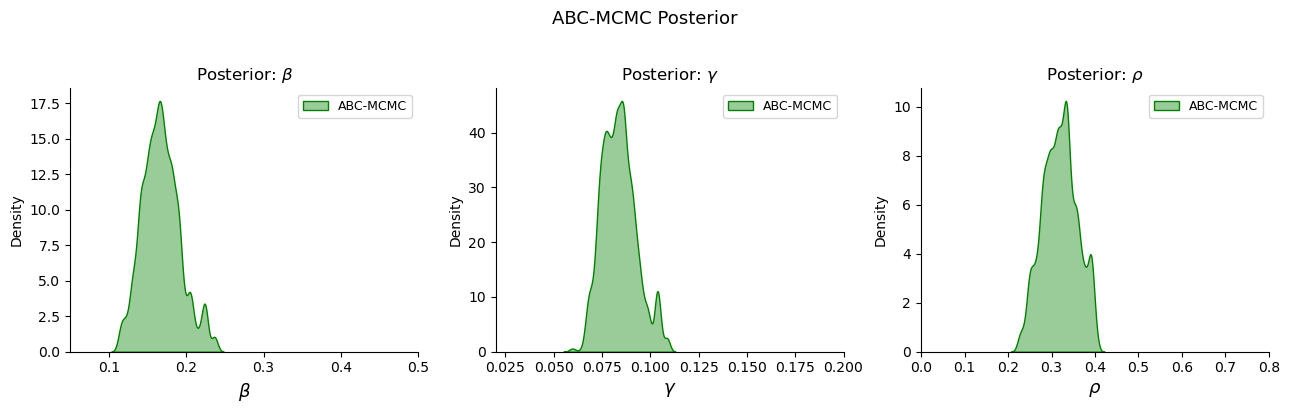

In [21]:
# Solo ABC-MCMC posterior
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.4, label="ABC-MCMC", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("ABC-MCMC Posterior", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

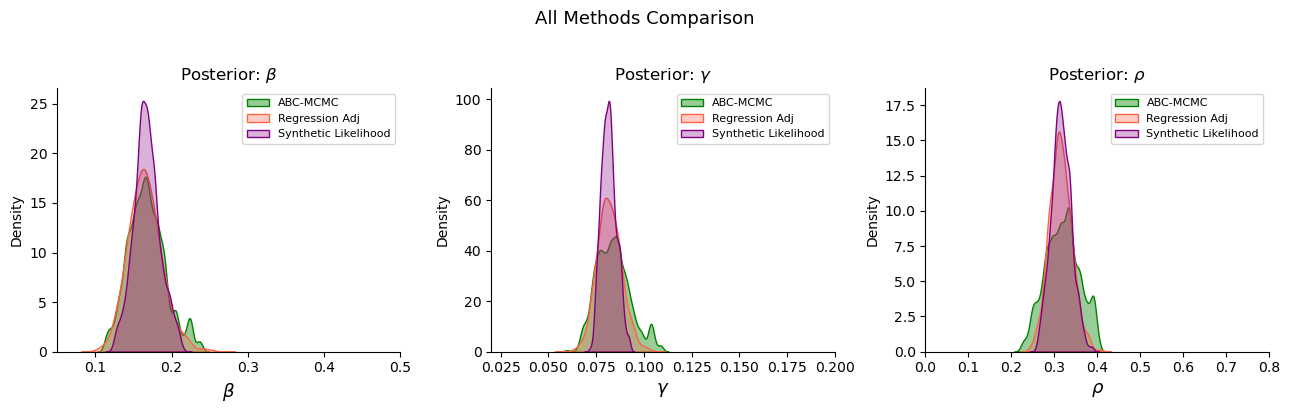


ABC-MCMC posterior means (after burn-in):
  beta  = 0.1673 ± 0.0244
  gamma = 0.0837 ± 0.0089
  rho   = 0.3188 ± 0.0395


In [22]:
# Discard burn-in
burnin_mcmc = 1000
chain_mcmc_trimmed = chain_mcmc[burnin_mcmc:]

PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.4, label="ABC-MCMC", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.3, label="Synthetic Likelihood", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("All Methods Comparison", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print("\nABC-MCMC posterior means (after burn-in):")
print(f"  beta  = {chain_mcmc_trimmed[:, 0].mean():.4f} ± {chain_mcmc_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_mcmc_trimmed[:, 1].mean():.4f} ± {chain_mcmc_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_mcmc_trimmed[:, 2].mean():.4f} ± {chain_mcmc_trimmed[:, 2].std():.4f}")

## Comparison of the 4 Methods

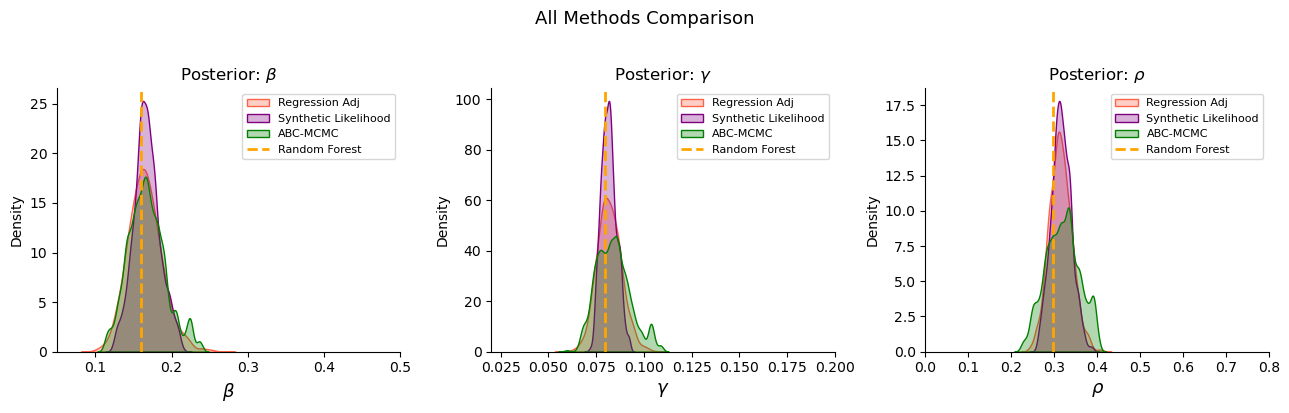

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.3, label="Synthetic Likelihood", clip=bounds)
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.3, label="ABC-MCMC", clip=bounds)
    rf_vals = [beta_pred, gamma_pred, rho_pred]
    ax.axvline(rf_vals[j], color="orange", linewidth=2,
               linestyle="--", label="Random Forest")
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("All Methods Comparison", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
print(f"{'Method':<25} {'beta':>8} {'gamma':>8} {'rho':>8}")
print("-" * 52)
print(f"{'Rejection ABC':<25} {params_accepted[:,0].mean():>8.4f} {params_accepted[:,1].mean():>8.4f} {params_accepted[:,2].mean():>8.4f}")
print(f"{'Regression Adjustment':<25} {params_adjusted[:,0].mean():>8.4f} {params_adjusted[:,1].mean():>8.4f} {params_adjusted[:,2].mean():>8.4f}")
print(f"{'Random Forest':<25} {beta_pred:>8.4f} {gamma_pred:>8.4f} {rho_pred:>8.4f}")
print(f"{'Synthetic Likelihood':<25} {chain_sl_trimmed[:,0].mean():>8.4f} {chain_sl_trimmed[:,1].mean():>8.4f} {chain_sl_trimmed[:,2].mean():>8.4f}")
print(f"{'ABC-MCMC':<25} {chain_mcmc_trimmed[:,0].mean():>8.4f} {chain_mcmc_trimmed[:,1].mean():>8.4f} {chain_mcmc_trimmed[:,2].mean():>8.4f}")

Method                        beta    gamma      rho
----------------------------------------------------
Rejection ABC               0.1893   0.0897   0.3330
Regression Adjustment       0.1652   0.0818   0.3140
Random Forest               0.1606   0.0798   0.2967
Synthetic Likelihood        0.1671   0.0815   0.3157
ABC-MCMC                    0.1673   0.0837   0.3188


add SMC-ABC here

## SMC-ABC

This section adds Toni et al.-style SMC-ABC after rejection ABC. It runs a sequence of decreasing tolerances, then reuses and perturbs previously accepted particles instead of restarting from the prior at every stage. That is usually more simulation-efficient once a rough posterior region has been found.

In [25]:
from scipy.special import logsumexp

PARAM_NAMES_SMC = ["beta", "gamma", "rho"]
PRIOR_BOUNDS_SMC = np.array([
    PRIOR_BETA,
    PRIOR_GAMMA,
    PRIOR_RHO,
], dtype=float)

SMC_SUMMARY_IDX = np.array(FINAL_JOINT, dtype=int)
SMC_SUMMARY_NAMES = [SUMMARY_NAMES[i] for i in SMC_SUMMARY_IDX]


def distance_fn(s_sim, s_obs, scale=None):
    s_sim = np.asarray(s_sim, dtype=float)
    s_obs = np.asarray(s_obs, dtype=float)
    diff = s_sim - s_obs

    if scale is not None:
        scale = np.asarray(scale, dtype=float)
        scale = np.where(scale == 0, 1.0, scale)
        diff = diff / scale

    return float(np.linalg.norm(diff))


def sample_prior(rng):
    return np.array([
        rng.uniform(low, high) for low, high in PRIOR_BOUNDS_SMC
    ], dtype=float)


def in_prior_support(theta):
    theta = np.asarray(theta, dtype=float)
    return bool(np.all((theta >= PRIOR_BOUNDS_SMC[:, 0]) & (theta <= PRIOR_BOUNDS_SMC[:, 1])))


def prior_pdf(theta):
    if not in_prior_support(theta):
        return 0.0

    widths = PRIOR_BOUNDS_SMC[:, 1] - PRIOR_BOUNDS_SMC[:, 0]
    return float(np.prod(1.0 / widths))


def perturb_theta(theta, cov, rng):
    theta = np.asarray(theta, dtype=float)
    try:
        proposal = rng.multivariate_normal(theta, cov, check_valid="ignore")
    except Exception:
        return None

    if not in_prior_support(proposal):
        return None

    return proposal


def weighted_cov(X, w):
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 0.0, None)
    total = np.sum(w)
    if not np.isfinite(total) or total <= 0:
        w = np.full(len(w), 1.0 / len(w), dtype=float)
    else:
        w = w / total

    mean = np.sum(X * w[:, None], axis=0)
    Xm = X - mean
    denom = 1.0 - np.sum(w ** 2)
    if denom <= 1e-12:
        denom = 1.0

    cov = (Xm * w[:, None]).T @ Xm / denom
    return 0.5 * (cov + cov.T)


def ess(weights):
    weights = np.asarray(weights, dtype=float)
    weights = np.clip(weights, 0.0, None)
    total = np.sum(weights)
    if not np.isfinite(total) or total <= 0:
        return 0.0
    weights = weights / total
    return float(1.0 / np.sum(weights ** 2))


def _stabilize_cov(cov, jitter=1e-9):
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    scale = max(1.0, float(np.trace(cov)) / cov.shape[0])
    return cov + (jitter * scale) * np.eye(cov.shape[0])


def _kernel_mixture_logpdf(theta, particles_prev, weights_prev, cov):
    log_terms = []
    for theta_prev, weight_prev in zip(particles_prev, weights_prev):
        if weight_prev <= 0:
            continue
        try:
            log_density = multivariate_normal.logpdf(
                theta,
                mean=theta_prev,
                cov=cov,
                allow_singular=True,
            )
        except Exception:
            continue

        if np.isfinite(log_density):
            log_terms.append(np.log(weight_prev) + log_density)

    if not log_terms:
        return -np.inf

    return float(logsumexp(log_terms))


def smc_abc(
    n_particles,
    eps_schedule,
    simulate_fn,
    summary_fn,
    s_obs,
    rng,
    scale=None,
    max_tries_per_particle=10000,
    eps_quantiles=None,
):
    eps_schedule = np.atleast_1d(np.asarray(eps_schedule, dtype=float))
    if eps_schedule.ndim != 1 or len(eps_schedule) == 0:
        raise ValueError("eps_schedule must contain at least one tolerance")

    if eps_quantiles is None:
        eps_quantiles = []
    eps_quantiles = np.asarray(eps_quantiles, dtype=float)

    fixed_mode = len(eps_schedule) > 1
    if fixed_mode and len(eps_quantiles) > 0:
        raise ValueError("Use either a full eps_schedule or eps_schedule[0] + eps_quantiles")

    if fixed_mode:
        n_pops = len(eps_schedule)
    else:
        n_pops = 1 + len(eps_quantiles)

    s_obs = np.asarray(s_obs, dtype=float)

    particles_list = []
    weights_list = []
    distances_list = []
    summaries_list = []
    acceptance_rates = []
    covariances = []
    eps_used = []

    # Population 0: plain rejection ABC from the prior.
    eps0 = float(eps_schedule[0])
    eps_used.append(eps0)

    pop_particles = []
    pop_distances = []
    pop_summaries = []
    total_tries = 0

    for i in range(n_particles):
        accepted = False
        tries = 0

        while not accepted:
            tries += 1
            total_tries += 1
            if tries > max_tries_per_particle:
                raise RuntimeError(
                    f"Population 0, particle {i}: exceeded max_tries_per_particle={max_tries_per_particle}"
                )

            theta = sample_prior(rng)
            sim_data = simulate_fn(theta, rng)
            s_sim = np.asarray(summary_fn(sim_data), dtype=float)
            dist = distance_fn(s_sim, s_obs, scale=scale)

            if dist <= eps0:
                pop_particles.append(theta)
                pop_distances.append(dist)
                pop_summaries.append(s_sim)
                accepted = True

    particles = np.asarray(pop_particles, dtype=float)
    weights = np.full(n_particles, 1.0 / n_particles, dtype=float)
    distances = np.asarray(pop_distances, dtype=float)
    summaries = np.asarray(pop_summaries, dtype=float)

    particles_list.append(particles)
    weights_list.append(weights)
    distances_list.append(distances)
    summaries_list.append(summaries)
    acceptance_rates.append(n_particles / total_tries)
    covariances.append(None)

    # Populations t >= 1: perturb previous particles and reweight.
    for t in range(1, n_pops):
        prev_particles = particles_list[-1]
        prev_weights = weights_list[-1]
        kernel_cov = _stabilize_cov(2.0 * weighted_cov(prev_particles, prev_weights))

        if fixed_mode:
            eps_t = float(eps_schedule[t])
        else:
            q = float(eps_quantiles[t - 1])
            eps_t = float(np.quantile(distances_list[-1], q))
        eps_used.append(eps_t)

        pop_particles = []
        pop_log_weights = []
        pop_distances = []
        pop_summaries = []
        total_tries = 0

        for i in range(n_particles):
            accepted = False
            tries = 0

            while not accepted:
                tries += 1
                total_tries += 1
                if tries > max_tries_per_particle:
                    raise RuntimeError(
                        f"Population {t}, particle {i}: exceeded max_tries_per_particle={max_tries_per_particle}"
                    )

                parent_idx = rng.choice(len(prev_particles), p=prev_weights)
                theta = perturb_theta(prev_particles[parent_idx], kernel_cov, rng)
                if theta is None:
                    continue

                sim_data = simulate_fn(theta, rng)
                s_sim = np.asarray(summary_fn(sim_data), dtype=float)
                dist = distance_fn(s_sim, s_obs, scale=scale)

                if dist <= eps_t:
                    log_prior = np.log(max(prior_pdf(theta), 1e-300))
                    log_denom = _kernel_mixture_logpdf(theta, prev_particles, prev_weights, kernel_cov)
                    log_weight = log_prior - log_denom

                    pop_particles.append(theta)
                    pop_log_weights.append(log_weight)
                    pop_distances.append(dist)
                    pop_summaries.append(s_sim)
                    accepted = True

        pop_particles = np.asarray(pop_particles, dtype=float)
        pop_log_weights = np.asarray(pop_log_weights, dtype=float)
        pop_distances = np.asarray(pop_distances, dtype=float)
        pop_summaries = np.asarray(pop_summaries, dtype=float)

        if np.any(~np.isfinite(pop_log_weights)):
            pop_weights = np.full(n_particles, 1.0 / n_particles, dtype=float)
        else:
            pop_log_weights = pop_log_weights - logsumexp(pop_log_weights)
            pop_weights = np.exp(pop_log_weights)

        pop_weights = np.clip(pop_weights, 0.0, None)
        weight_total = np.sum(pop_weights)
        if not np.isfinite(weight_total) or weight_total <= 0:
            pop_weights = np.full(n_particles, 1.0 / n_particles, dtype=float)
        else:
            pop_weights = pop_weights / weight_total

        particles_list.append(pop_particles)
        weights_list.append(pop_weights)
        distances_list.append(pop_distances)
        summaries_list.append(pop_summaries)
        acceptance_rates.append(n_particles / total_tries)
        covariances.append(kernel_cov)

    return {
        "particles": particles_list,
        "weights": weights_list,
        "distances": distances_list,
        "summaries": summaries_list,
        "acceptance_rates": acceptance_rates,
        "covariances": covariances,
        "eps_schedule": np.asarray(eps_used, dtype=float),
    }

In [26]:
def simulate_model(theta, rng):
    beta, gamma, rho = theta
    return simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)


def summary_model(sim_data):
    infected_fraction, rewire_counts, degree_histogram = sim_data
    return calc_summaries(infected_fraction, rewire_counts, degree_histogram)[SMC_SUMMARY_IDX]


s_obs_smc = np.asarray(s_obs[SMC_SUMMARY_IDX], dtype=float)
summary_scale = None
if "sims_prior" in globals():
    summary_scale = sims_prior[:, SMC_SUMMARY_IDX].std(axis=0)
    summary_scale = np.where(summary_scale == 0, 1.0, summary_scale)

if summary_scale is None:
    summary_scale = np.ones(len(SMC_SUMMARY_IDX), dtype=float)

pilot_rng = np.random.default_rng(2026)
N_PILOT = 1000
pilot_distances = []
for _ in range(N_PILOT):
    theta = sample_prior(pilot_rng)
    sim_data = simulate_model(theta, pilot_rng)
    s_sim = summary_model(sim_data)
    pilot_distances.append(distance_fn(s_sim, s_obs_smc, scale=summary_scale))

pilot_distances = np.asarray(pilot_distances, dtype=float)
eps0 = float(np.quantile(pilot_distances, 0.90))
eps_quantiles = [0.70, 0.50, 0.35, 0.20]

print("EDIT THESE TO MATCH YOUR CURRENT NOTEBOOK")
print("Selected summary indices:", SMC_SUMMARY_IDX.tolist())
print("Selected summaries:", SMC_SUMMARY_NAMES)
print("Initial epsilon (pilot 90th percentile):", round(eps0, 4))
print("Adaptive quantiles for later populations:", eps_quantiles)

smc_result = smc_abc(
    n_particles=300,
    eps_schedule=[eps0],
    eps_quantiles=eps_quantiles,
    simulate_fn=simulate_model,
    summary_fn=summary_model,
    s_obs=s_obs_smc,
    rng=np.random.default_rng(7),
    scale=summary_scale,
    max_tries_per_particle=10000,
)

smc_particles = smc_result["particles"]
smc_weights = smc_result["weights"]
smc_distances = smc_result["distances"]
smc_summaries = smc_result["summaries"]
smc_acceptance_rates = smc_result["acceptance_rates"]
smc_covariances = smc_result["covariances"]
print("Final eps schedule used:", np.round(smc_result["eps_schedule"], 4).tolist())
print(f"Completed {len(smc_particles)} populations.")

EDIT THESE TO MATCH YOUR CURRENT NOTEBOOK
Selected summary indices: [3, 15, 10, 5, 4, 6, 2, 7, 12, 0, 17, 18, 13, 8, 1, 19]
Selected summaries: ['early_mass', 'early_rewire', 'slope_growth', 't_10', 't_5', 't_20', 'auc', 'duration_10', 'total_rewire', 'peak', 'rewire_to_auc', 'corr_I_R', 'max_rewire', 'inc_peak', 't_peak', 'corr_dI_R']
Initial epsilon (pilot 90th percentile): 6.7055
Adaptive quantiles for later populations: [0.7, 0.5, 0.35, 0.2]
Final eps schedule used: [6.7055, 3.9198, 2.5973, 1.8708, 1.1366]
Completed 5 populations.


In [27]:
diag_rows = []
for pop_idx, (eps, dist, weights, acc_rate) in enumerate(
    zip(smc_result["eps_schedule"], smc_distances, smc_weights, smc_acceptance_rates)
):
    diag_rows.append({
        "population": pop_idx,
        "epsilon": float(eps),
        "acceptance_rate": float(acc_rate),
        "ess": ess(weights),
        "min_distance": float(np.min(dist)),
        "median_distance": float(np.median(dist)),
        "max_distance": float(np.max(dist)),
    })

diag_df = pd.DataFrame(diag_rows)
print(diag_df.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))

 population  epsilon  acceptance_rate      ess  min_distance  median_distance  max_distance
          0   6.7055           0.8876 300.0000        0.8023           3.1255        6.7025
          1   3.9198           0.2611 286.9693        0.7414           2.5973        3.9144
          2   2.5973           0.1524 290.6307        0.5815           2.0445        2.5970
          3   1.8708           0.1130 294.4480        0.4258           1.4838        1.8704
          4   1.1366           0.0638 293.6596        0.3256           0.9290        1.1319


In [28]:
import matplotlib
print(matplotlib.__version__)

3.7.2


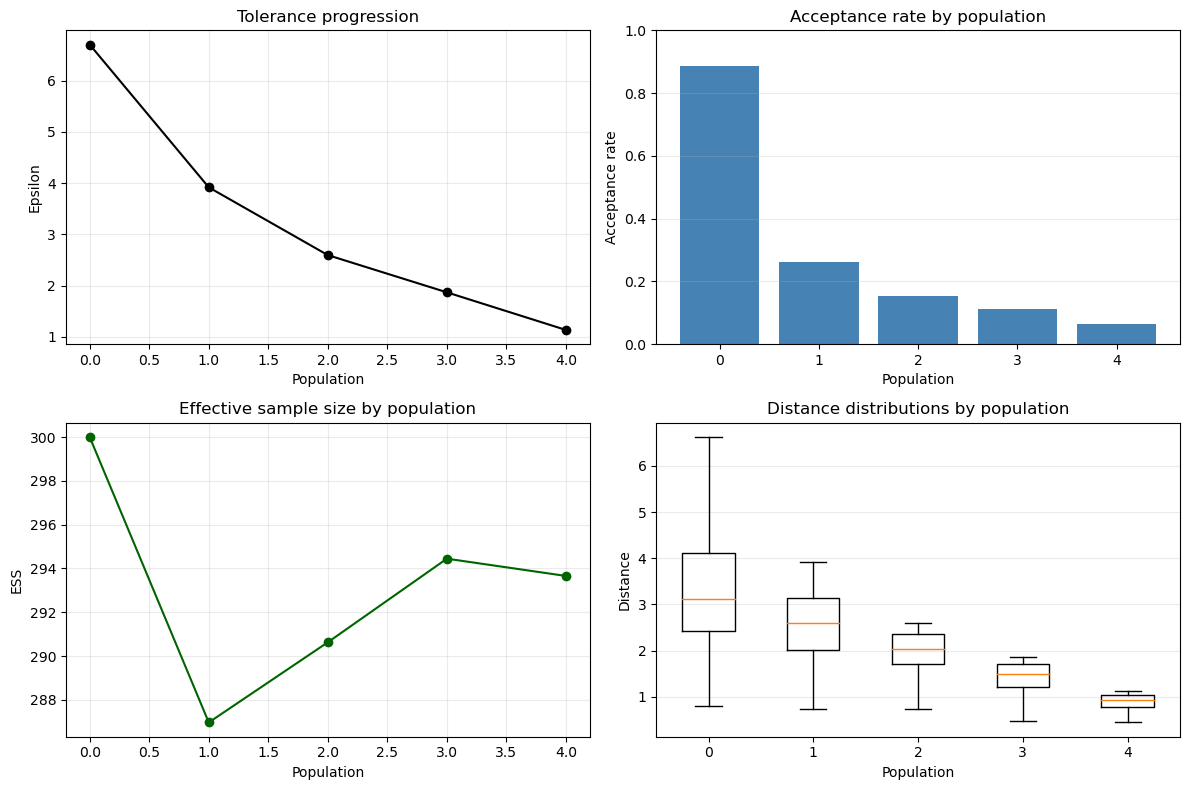

Final population index: 4
Final epsilon: 1.1365808513648128


In [30]:
population_ids = np.arange(len(smc_result["eps_schedule"]))
final_idx = len(smc_result["eps_schedule"]) - 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# A. Tolerance progression
ax = axes[0, 0]
ax.plot(population_ids, smc_result["eps_schedule"], marker="o", color="black")
ax.set_xlabel("Population")
ax.set_ylabel("Epsilon")
ax.set_title("Tolerance progression")
ax.grid(alpha=0.25)

# B. Acceptance rate by population
ax = axes[0, 1]
ax.bar(population_ids, smc_acceptance_rates, color="steelblue")
ax.set_xlabel("Population")
ax.set_ylabel("Acceptance rate")
ax.set_title("Acceptance rate by population")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)

# C. ESS by population
ax = axes[1, 0]
ess_values = [ess(w) for w in smc_weights]
ax.plot(population_ids, ess_values, marker="o", color="darkgreen")
ax.set_xlabel("Population")
ax.set_ylabel("ESS")
ax.set_title("Effective sample size by population")
ax.grid(alpha=0.25)

# D. Distance distributions by population
ax = axes[1, 1]
ax.boxplot(smc_distances, labels=[str(i) for i in population_ids], showfliers=False)
ax.set_xlabel("Population")
ax.set_ylabel("Distance")
ax.set_title("Distance distributions by population")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("Final population index:", final_idx)
print("Final epsilon:", float(smc_result["eps_schedule"][-1]))

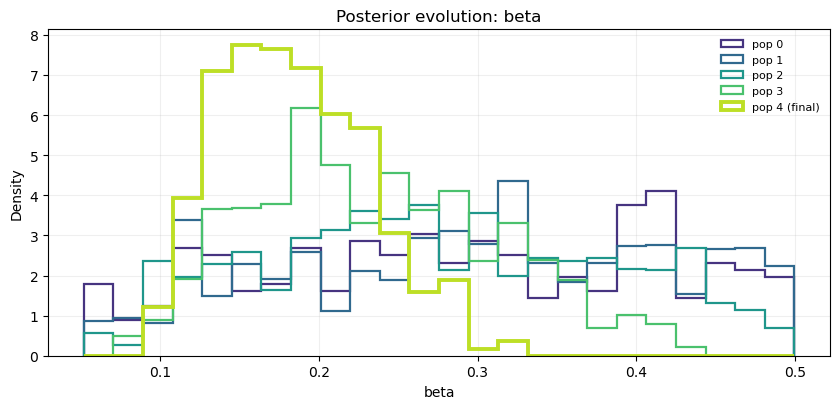

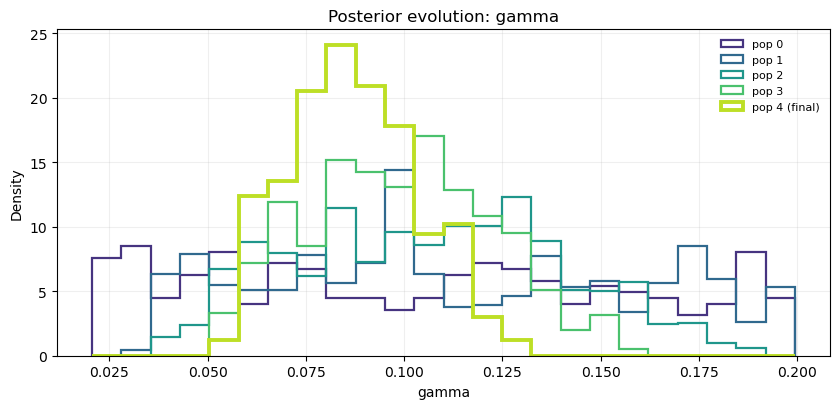

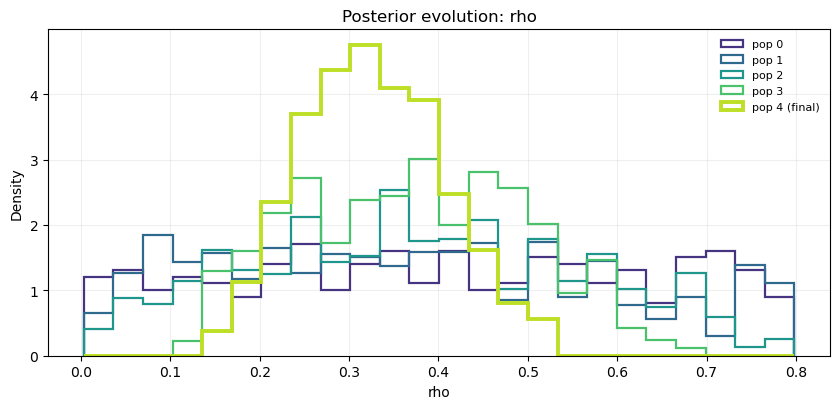

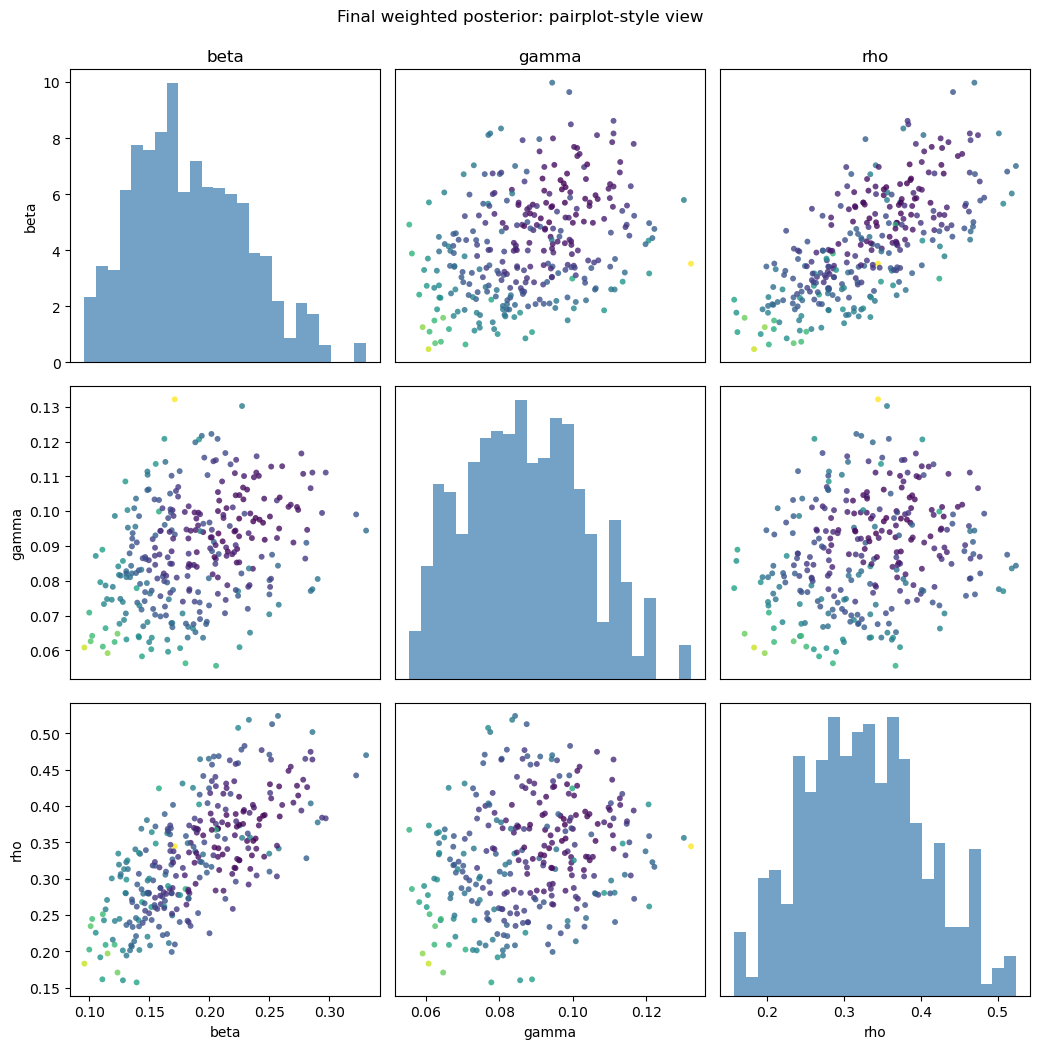

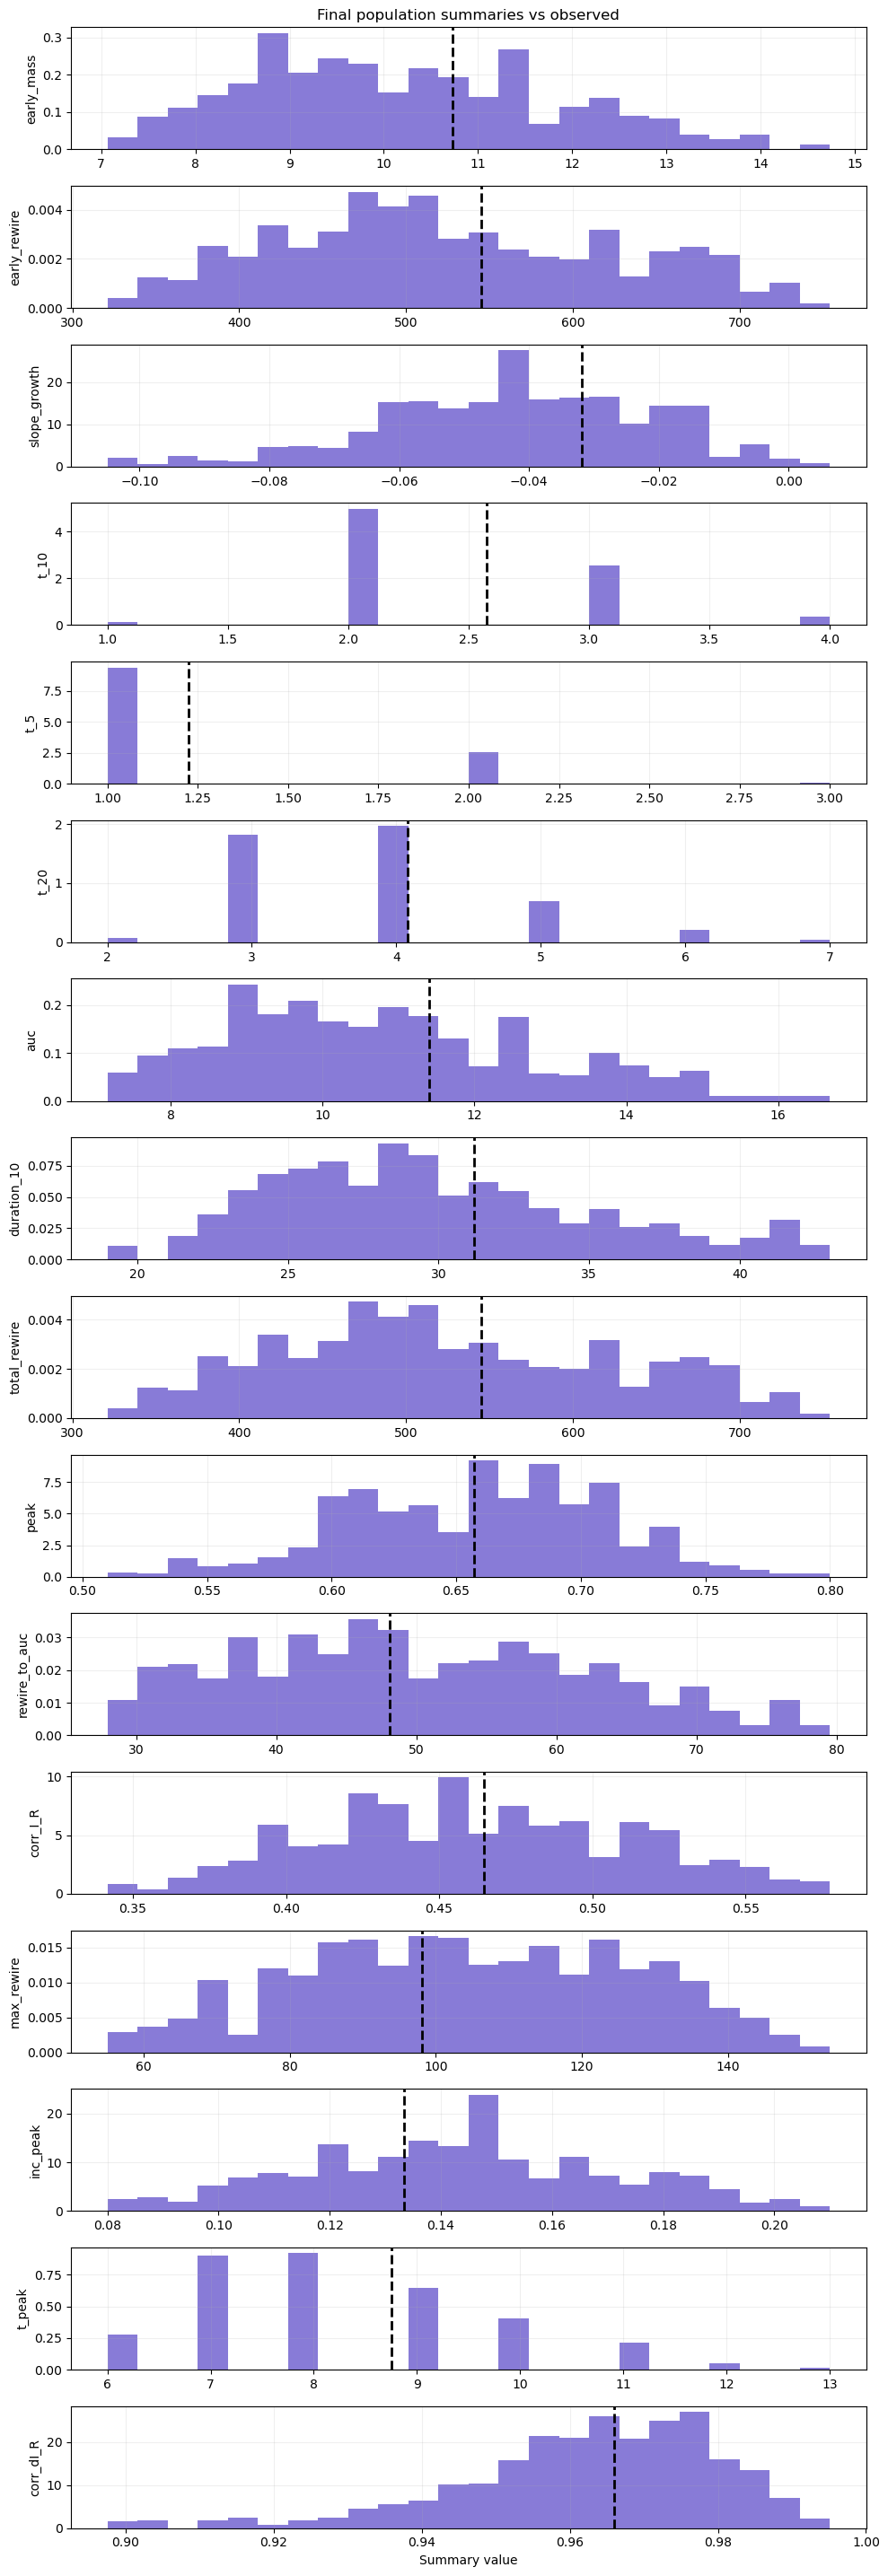

In [31]:
final_particles = smc_particles[-1]
final_weights = smc_weights[-1]
final_summaries = smc_summaries[-1]

# E. Posterior evolution for each parameter
for j, param_name in enumerate(PARAM_NAMES_SMC):
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    all_values = np.concatenate([particles[:, j] for particles in smc_particles])
    x_min = float(np.min(all_values))
    x_max = float(np.max(all_values))
    if x_min == x_max:
        x_min -= 1e-6
        x_max += 1e-6
    bins = np.linspace(x_min, x_max, 25)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(smc_particles)))

    for pop_idx, (particles, weights, color) in enumerate(zip(smc_particles, smc_weights, colors)):
        line_width = 2.8 if pop_idx == len(smc_particles) - 1 else 1.6
        label = f"pop {pop_idx}"
        if pop_idx == len(smc_particles) - 1:
            label += " (final)"

        ax.hist(
            particles[:, j],
            bins=bins,
            weights=weights,
            density=True,
            histtype="step",
            linewidth=line_width,
            color=color,
            label=label,
        )

    ax.set_xlabel(param_name)
    ax.set_ylabel("Density")
    ax.set_title(f"Posterior evolution: {param_name}")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# F. Final weighted posterior pairplot-style view
n_params = len(PARAM_NAMES_SMC)
fig, axes = plt.subplots(n_params, n_params, figsize=(10.5, 10.5))

for row in range(n_params):
    for col in range(n_params):
        ax = axes[row, col]
        if row == col:
            values = final_particles[:, col]
            x_min = float(np.min(values))
            x_max = float(np.max(values))
            if x_min == x_max:
                x_min -= 1e-6
                x_max += 1e-6
            bins = np.linspace(x_min, x_max, 25)
            ax.hist(values, bins=bins, weights=final_weights, density=True, color="steelblue", alpha=0.75)
        else:
            ax.scatter(
                final_particles[:, col],
                final_particles[:, row],
                c=final_weights,
                cmap="viridis",
                s=18,
                alpha=0.8,
                edgecolors="none",
            )

        if row == n_params - 1:
            ax.set_xlabel(PARAM_NAMES_SMC[col])
        else:
            ax.set_xticks([])

        if col == 0:
            ax.set_ylabel(PARAM_NAMES_SMC[row])
        else:
            ax.set_yticks([])

        if row == 0:
            ax.set_title(PARAM_NAMES_SMC[col])

plt.suptitle("Final weighted posterior: pairplot-style view", y=0.995)
plt.tight_layout()
plt.show()

# G. Observed-vs-accepted summary comparison for final population
n_summaries = len(SMC_SUMMARY_IDX)
fig, axes = plt.subplots(n_summaries, 1, figsize=(10, 1.8 * n_summaries), sharex=False)
if n_summaries == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    values = final_summaries[:, j]
    x_min = float(np.min(values))
    x_max = float(np.max(values))
    if x_min == x_max:
        x_min -= 1e-6
        x_max += 1e-6
    bins = np.linspace(x_min, x_max, 25)
    ax.hist(values, bins=bins, weights=final_weights, color="slateblue", alpha=0.8, density=True)
    ax.axvline(s_obs_smc[j], color="black", linestyle="--", linewidth=2)
    ax.set_ylabel(SMC_SUMMARY_NAMES[j])
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Summary value")
axes[0].set_title("Final population summaries vs observed")
plt.tight_layout()
plt.show()